# Random Forest Model

In this notebook we train our second model, a Random Forest classifier.
After establishing a baseline with Logistic Regression, we now move to a more
powerful approach that can capture patterns a linear model simply cannot see.

The idea behind Random Forest is straightforward: instead of trusting one single
decision tree, we build hundreds of them and let them vote together.
The majority wins, and the result is almost always better than any individual tree.

## Importing Libraries

Same evaluation tools as the Logistic Regression notebook so we can compare
the results fairly at the end.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

## Loading the Preprocessed Data

We load the exact same arrays that were used in the Logistic Regression notebook.
This is important, if each model trained on a different split, the comparison
between them would not be fair.

In [5]:
X_train = np.load('../data/X_train_processed.npy')
X_test  = np.load('../data/X_test_processed.npy')
y_train = np.load('../data/y_train.npy')
y_test  = np.load('../data/y_test.npy')
feature_names = np.load('../data/feature_names.npy', allow_pickle=True)

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)

print(f'\nClass distribution in training set:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Good credit' if u == 0 else 'Bad credit'
    print(f'  {label} ({int(u)}): {c} samples ({c/len(y_train)*100:.1f}%)')

X_train shape: (800, 44)
X_test shape:  (200, 44)

Class distribution in training set:
  Good credit (0): 560 samples (70.0%)
  Bad credit (1): 240 samples (30.0%)


## What is a Random Forest?

Let's start with a single **decision tree**. It works by asking a series of
yes/no questions about the features until it reaches a final answer:

```
Does the applicant have a negative checking account balance?
├── Yes → Is the credit amount above 5000?
│         ├── Yes → Bad Credit
│         └── No  → Good Credit
└── No  → Good Credit
```

A single tree is easy to understand but has one big problem: it tends to
memorise the training data instead of learning general patterns.
Give it slightly different data and its predictions can change dramatically.

A Random Forest fixes this with two simple tricks:

**1. Bagging** — instead of one tree trained on all the data, we train hundreds
of trees, each on a different random sample of the training data.
Each tree sees a slightly different version of reality, so they make different mistakes.

**2. Random features** — at every split, each tree only considers a random
subset of features. This forces the trees to be different from each other
and prevents them all from depending on the same few dominant features.

The final prediction is a **majority vote** across all trees:

$$\hat{y} = \text{mode}\left(\hat{y}_1, \hat{y}_2, \dots, \hat{y}_{300}\right)$$

Because each tree makes different mistakes, those mistakes cancel each other out
when we average across all 300 trees. This is the core insight behind ensemble learning:
a crowd of imperfect models beats a single perfect-looking one.

## Model Settings

Before training we define the hyperparameters — these are settings we choose
ourselves rather than values the model learns from the data.

- **`n_estimators=300`**: we build 300 trees. More trees means more stable
  predictions, but beyond a certain point the improvement becomes very small.

- **`max_depth=10`** : each tree can ask at most 10 questions deep.
  Without this limit, trees grow until every leaf has a single sample,
  which is just memorising the training data.

- **`min_samples_split=10`** : a group of samples needs at least 10 members
  before the tree is allowed to split it further. Prevents overly specific rules.

- **`min_samples_leaf=4`** : every final leaf must contain at least 4 samples.
  Another safety net against the model creating rules that apply to almost nobody.

- **`max_features='sqrt'`** : at each split, consider only the square root of
  the total features. This is what keeps the trees different from each other.

- **`class_weight='balanced'`** : the dataset has 70% good credit and 30% bad.
  Without this, the model would be biased toward predicting good credit.
  Balanced weighting makes the model treat both classes with equal importance.

- **`n_jobs=-1`** : use all available CPU cores to train trees in parallel.
  Random Forest can do this because each tree is built independently.

## Training the Model

Training 300 trees sounds like a lot but it only takes a few seconds
because they are all built in parallel.

In [6]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=10, min_samples_leaf=4, max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)
print('Model trained successfully.')
print(f'Number of trees: {rf_model.n_estimators}')
print(f'Number of features: {rf_model.n_features_in_}')

Model trained successfully.
Number of trees: 300
Number of features: 44


## Making Predictions

We generate two types of output:
- Hard labels (0 or 1) for accuracy and the confusion matrix
- Probabilities for the ROC-AUC score, which gives a more complete
  picture of model performance than accuracy alone

In [7]:
y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print('Sample predictions (first 10):')
print('Predicted:', y_pred[:10])
print('Actual:   ', y_test[:10].astype(int))

Sample predictions (first 10):
Predicted: [0 0 1 1 0 0 0 0 1 0]
Actual:    [0 0 1 0 1 0 0 0 0 0]


## Evaluating the Model

We use the same metrics as Logistic Regression so the comparison is straightforward.
The two numbers we care most about are:

- **ROC-AUC** — overall ability to separate good from bad applicants
- **Recall for Bad Credit** — how many bad applicants we actually caught

In [8]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_proba)

print('=' * 45)
print('         RANDOM FOREST RESULTS')
print('=' * 45)
print(f'  Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'  ROC-AUC  : {roc_auc:.4f}')
print('=' * 45)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Good Credit', 'Bad Credit']))

         RANDOM FOREST RESULTS
  Accuracy : 0.7350 (73.50%)
  ROC-AUC  : 0.7920

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.84      0.76      0.80       140
  Bad Credit       0.55      0.67      0.60        60

    accuracy                           0.73       200
   macro avg       0.70      0.72      0.70       200
weighted avg       0.75      0.73      0.74       200



The Random Forest achieved an accuracy of 73.50% and a ROC-AUC of 0.7920, a small but real improvement over Logistic Regression's 0.7819.

For the Good Credit class, precision improved to 0.84 and recall to 0.76, the model is doing a better job correctly identifying good applicants compared to before.

For the Bad Credit class, recall dropped slightly to 0.67 compared to Logistic Regression's 0.77, meaning we are now missing more bad applicants. However precision improved to 0.55, so the applicants we do flag as bad are slightly more likely to actually be bad. This is a classic precision-recall tradeoff, the model became more conservative in flagging bad credit.

The ROC-AUC improvement tells us the model's overall ability to rank bad applicants above good ones got better, even if the recall on bad credit dropped at the default 0.5 threshold. This is why ROC-AUC is more reliable than looking at recall alone.

## Confusion Matrix

The confusion matrix breaks down exactly where the model was right and where it was wrong.
The two cells we focus on are:

- **Bottom-left (False Negatives)** — bad applicants we missed. These are approved
  loans that will default. The most expensive mistake.
- **Top-right (False Positives)** — good applicants we wrongly rejected.
  Less damaging but still a cost — lost business from good customers.

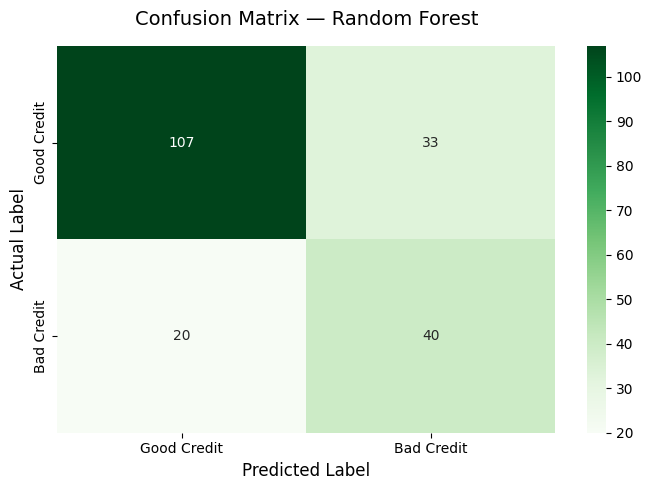

True Negatives  (correctly predicted good): 107
False Positives (good applicants flagged):  33
False Negatives (bad applicants missed):    20  <- most costly
True Positives  (correctly caught bad):     40


In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens',
    xticklabels=['Good Credit', 'Bad Credit'],
    yticklabels=['Good Credit', 'Bad Credit']
)
plt.title('Confusion Matrix — Random Forest', fontsize=14, pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted good): {tn}')
print(f'False Positives (good applicants flagged):  {fp}')
print(f'False Negatives (bad applicants missed):    {fn}  <- most costly')
print(f'True Positives  (correctly caught bad):     {tp}')

Out of 200 test applicants, the model correctly classified 107 good credit and 40 bad credit applicants.

The False Negatives went up to 20 compared to Logistic Regression's 14 — meaning Random Forest missed 6 more bad applicants. Out of 60 actual bad applicants, 20 slipped through, which is 33% of all bad cases going undetected.

However the False Positives dropped significantly to 33 from Logistic Regression's 41 — meaning we are wrongly rejecting 8 fewer good customers. The model became more precise but less aggressive in catching bad applicants.

This confirms the tradeoff we saw in the classification report — Random Forest is more careful about who it flags, which means fewer false alarms but also more missed bad applicants compared to Logistic Regression.

## ROC Curve

The ROC curve shows the tradeoff between catching bad applicants (True Positive Rate)
and wrongly flagging good ones (False Positive Rate) across all possible thresholds.
The further the curve bends toward the top-left corner, the better the model.

/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


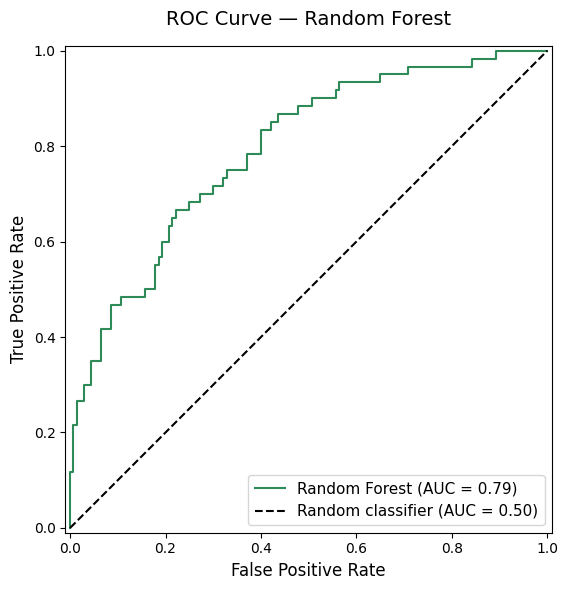

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba,
    name='Random Forest',
    color='seagreen',
    ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier (AUC = 0.50)')
ax.set_title('ROC Curve — Random Forest', fontsize=14, pad=15)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The curve sits well above the diagonal dashed line, confirming the model is significantly better than random guessing.

The AUC of 0.79 is a slight improvement over Logistic Regression's 0.78. The curve rises steeply in the early left region — meaning at low false positive rates the model already catches a good proportion of bad applicants. This is the ideal behaviour for a credit risk model where we want to catch bad applicants without flagging too many good ones.

The improvement over Logistic Regression is modest but consistent — Random Forest is making better use of the non-linear patterns in the data.

## Feature Importance

One of the best things about Random Forest is that it tells you which features
it found most useful. The importance score of a feature measures how much it
helped reduce uncertainty across all the splits in all 300 trees.

A higher score means the model relied on that feature more heavily
to separate good from bad applicants.

Note that unlike Logistic Regression coefficients, these scores only tell us
**how important** a feature was — not whether it pushed toward good or bad credit.

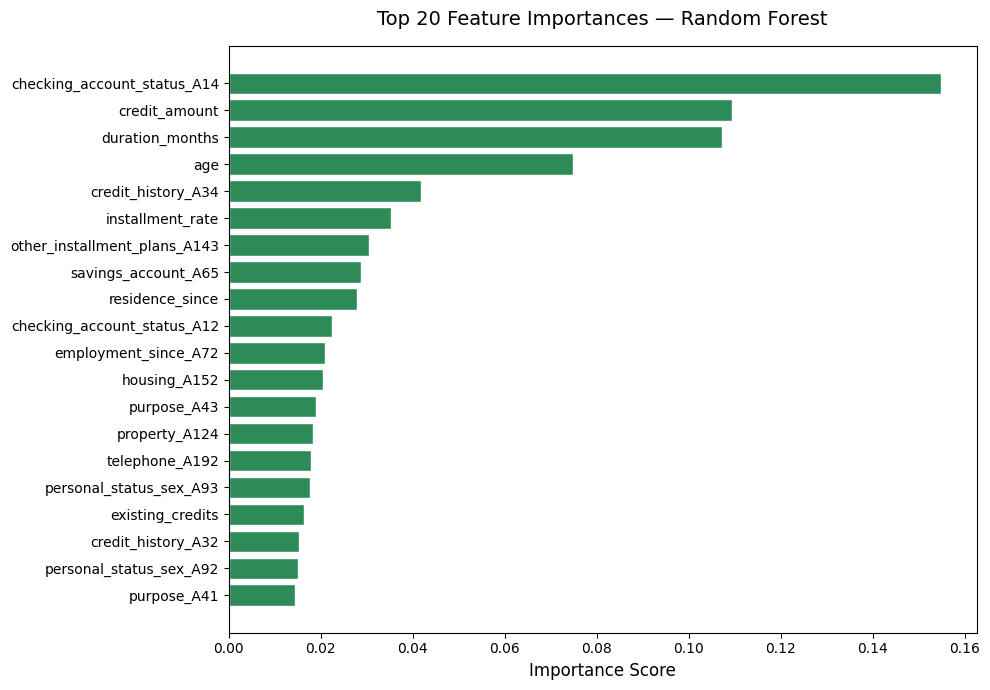

Top 10 most important features:
checking_account_status_A14     0.1548
credit_amount                   0.1094
duration_months                 0.1072
age                             0.0748
credit_history_A34              0.0417
installment_rate                0.0353
other_installment_plans_A143    0.0306
savings_account_A65             0.0288
residence_since                 0.0279
checking_account_status_A12     0.0225
dtype: float64


In [11]:
importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(range(len(top_features)),top_features.values[::-1],color='seagreen', edgecolor='white'
)
plt.yticks(range(len(top_features)), top_features.index[::-1], fontsize=10)
plt.title('Top 20 Feature Importances — Random Forest', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

print('Top 10 most important features:')
print(top_features.head(10).round(4))

The most important feature by far is `checking_account_status_A14` (no checking account) with a score of 0.155, the forest relied on this single feature more than any other to separate good from bad applicants. This aligns perfectly with Logistic Regression which also identified this as the strongest protective factor.

`credit_amount` (0.110) and `duration_months` (0.107) are the second and third most important, larger and longer loans carry more risk. These also appeared in the Logistic Regression top features, which gives us strong confidence that these three variables are genuinely predictive of credit risk and not just artifacts of one algorithm.
age (0.076) is notably more important here than in Logistic Regression, this suggests the relationship between age and credit risk is non-linear, something Random Forest can capture but Logistic Regression cannot.
`credit_history_A34` (0.042) also appears in both models' top lists, confirming that a critical credit history is a reliable signal regardless of which algorithm we use.

## Out-of-Bag Score

Random Forest has a built-in way to estimate how well it will perform on new data,
without needing to use the test set at all. It is called the **Out-of-Bag (OOB) score**.

Here is the idea: each tree is trained on a random sample of the training data.
On average, about 37% of training samples are not used for any given tree.
Those unused samples are called the out-of-bag samples for that tree.

The model evaluates each training sample using only the trees that never saw it.
This gives a free, honest estimate of real-world performance.

If the OOB score is close to the test accuracy, it means the model generalises well
and there is no suspicious gap between training and test performance.

In [12]:
rf_oob = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=10, min_samples_leaf=4, max_features='sqrt',
    class_weight='balanced', oob_score=True, random_state=42, n_jobs=-1)
rf_oob.fit(X_train, y_train)

print(f'OOB Score (internal estimate): {rf_oob.oob_score_:.4f}')
print(f'Test Accuracy (actual):        {accuracy:.4f}')
print(f'Difference:                    {abs(rf_oob.oob_score_ - accuracy):.4f}')
print()
if abs(rf_oob.oob_score_ - accuracy) < 0.05:
    print('The gap is small — the model generalises well to unseen data.')
else:
    print('The gap is notable — the model may be slightly overfitting.')

OOB Score (internal estimate): 0.7312
Test Accuracy (actual):        0.7350
Difference:                    0.0038

The gap is small — the model generalises well to unseen data.


The OOB score of 0.7312 is extremely close to the actual test accuracy of 0.7350, with a difference of only 0.0038 — less than half a percent.

This is a very reassuring result. It means the model is not memorising the training data — what it learned generalises consistently to data it has never seen. The OOB score acted as an honest internal check and it confirmed exactly what the test set showed.

## Saving the Model

We save the trained model so it can be loaded in the evaluation notebook
where all three models will be compared side by side.

In [15]:
os.makedirs('../models', exist_ok=True)

joblib.dump(rf_model, '../models/random_forest.pkl')
print('Model saved to ../models/random_forest.pkl')

rf_metrics = {
    'model':    'Random Forest',
    'accuracy': round(accuracy_score(y_test, y_pred), 4),
    'roc_auc':  round(roc_auc_score(y_test, y_pred_proba), 4)
}

print()
print('Metrics summary:')
for k, v in rf_metrics.items():
    print(f'  {k}: {v}')

Model saved to ../models/random_forest.pkl

Metrics summary:
  model: Random Forest
  accuracy: 0.735
  roc_auc: 0.792
